<a href="https://colab.research.google.com/github/lejhindary/MedStar-G5/blob/main/Copy_of_MedStarG5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import learning_curve

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_folder = "/content/drive/MyDrive/Group 5: Dereck Kaale/MIMIC-IV-ExtCardiacDiseases/Dataset"
os.listdir(data_folder)
mimic_folder = "/content/drive/MyDrive/Group 5: Dereck Kaale/mimiciv/3.1/"
os.listdir(mimic_folder)

Mounted at /content/drive


['index.html', 'hosp', 'icu']

In [ ]:
import os

# This is the path to the 'Group 5: Dereck Kaale' folder in your Drive
parent_data_path = "/content/drive/MyDrive/Group 5: Dereck Kaale/"

print(f"Checking contents of: {parent_data_path}")

if os.path.exists(parent_data_path):
    print("\nContents found:")
    for item in os.listdir(parent_data_path):
        print(f"- {item}")
    print("\nLook for a folder similar to 'MIMIC-IV-ExtCardiacDiseases' in the list above.")
    print("Once you find the correct folder name (e.g., 'MIMIC-IV-ExtCardiacDiseases_Corrected'),")
    print("you should update the `data_folder` variable in cell `z6JBTLhEwYxb` to reflect that exact path.")
    print("For example: `data_folder = \"/content/drive/MyDrive/Group 5: Dereck Kaale/MIMIC-IV-ExtCardiacDiseases_Corrected/Dataset\"`")
else:
    print(f"\nError: The directory '{parent_data_path}' does not exist. Please ensure your Google Drive is mounted correctly and this path is valid.")
    print("You might need to re-run `drive.mount('/content/drive')` or check the path to 'Group 5: Dereck Kaale'.")

Checking contents of: /content/drive/MyDrive/Group 5: Dereck Kaale/

Contents found:
- MIMIC-IV-ExtCardiacDiseases
- mimiciv

Look for a folder similar to 'MIMIC-IV-ExtCardiacDiseases' in the list above.
Once you find the correct folder name (e.g., 'MIMIC-IV-ExtCardiacDiseases_Corrected'),
you should update the `data_folder` variable in cell `z6JBTLhEwYxb` to reflect that exact path.
For example: `data_folder = "/content/drive/MyDrive/Group 5: Dereck Kaale/MIMIC-IV-ExtCardiacDiseases_Corrected/Dataset"`


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
heart_diagnoses = pd.read_csv(data_folder+"/heart_labevents_examination_group.csv")
true_heart_diagnoses = pd.read_csv(data_folder+"/heart_diagnoses_all_true.csv")

In [ ]:
true_heart_diagnoses[(true_heart_diagnoses['icd_code']=="I359") | (true_heart_diagnoses['icd_code']=="I350")].value_counts()

#I359 = nonrheumatic aortic valve disorder unspecified
#I350 nonrheumatic aortic valve stenosis
#I348 other nonrheumatic mitral valve disorder

,,,,,count
subject_id,hadm_id,seq_num,icd_code,long_title,
19965144,28838567,4,I359,"Nonrheumatic aortic valve disorder, unspecified",1
10004457,28723315,1,I359,"Nonrheumatic aortic valve disorder, unspecified",1
10017886,20015927,6,I359,"Nonrheumatic aortic valve disorder, unspecified",1
10035787,29728342,1,I350,Nonrheumatic aortic (valve) stenosis,1
10051074,21350747,8,I350,Nonrheumatic aortic (valve) stenosis,1
...,...,...,...,...,...
10394761,23737808,1,I359,"Nonrheumatic aortic valve disorder, unspecified",1
10388470,29742451,4,I350,Nonrheumatic aortic (valve) stenosis,1
10354217,22315422,4,I359,"Nonrheumatic aortic valve disorder, unspecified",1


In [ ]:
# pulls all icd codes
all_icd = true_heart_diagnoses[['icd_code', 'long_title']].drop_duplicates().sort_values('icd_code').reset_index(drop=True)
# filters vhd related codes
vhd_icd = all_icd[all_icd['long_title'].str.lower().str.contains('valve|rheumatic', na=False) ]
#filters ie related codes
ie_icd = all_icd[all_icd['long_title'].str.lower().str.contains('endocarditis', na=False)]
print(f"Number of VHD ICD codes: {len(vhd_icd)}")
print(vhd_icd.to_string())
print(f"\n Number of IE ICD codes: {len(ie_icd)}")
print(ie_icd.to_string())


Number of VHD ICD codes: 37
     icd_code                                                                  long_title
798      I050                                                   Rheumatic mitral stenosis
799      I051                                              Rheumatic mitral insufficiency
800      I052                                Rheumatic mitral stenosis with insufficiency
801      I060                                                   Rheumatic aortic stenosis
802      I061                                              Rheumatic aortic insufficiency
803      I062                                Rheumatic aortic stenosis with insufficiency
804      I071                                           Rheumatic tricuspid insufficiency
805      I078                                    Other rheumatic tricuspid valve diseases
806      I080                        Rheumatic disorders of both mitral and aortic valves
807      I081                     Rheumatic disorders of both mitral and

In [ ]:
#concatenating data tables section
df_adm = pd.read_csv(mimic_folder + 'hosp/admissions.csv')
df_pat = pd.read_csv(mimic_folder + 'hosp/patients.csv')
df_icu = pd.read_csv(mimic_folder + 'icu/icustays.csv')
df_dx   = pd.read_csv(data_folder + '/heart_diagnoses_all_true.csv')
df_labs = pd.read_csv(data_folder + '/heart_labevents_first_lab.csv')

In [ ]:
#list of icd codes that represents aortic stenosis
as_codes = ['I350', 'I352', 'I060', 'I062', 'I359']
#checks if the icd codes corresponds to as codes, returns true or false, keeps only the rows where its true, and also grabs the hadm id
as_ids = df_dx[df_dx['icd_code'].isin(as_codes)]['hadm_id'].unique()
#new dataframe that contains all of the as patients
df = pd.DataFrame({'hadm_id': as_ids})
print(f"AS patients: {len(df)}")

#same process as above but for mitral stenosis, aortic regurgitation, and mitral regurgitation
#mitral stenosis:
ms_codes = ['I050', 'I052', 'I342']
ms_ids = df_dx[df_dx['icd_code'].isin(ms_codes)]['hadm_id'].unique()
df_ms = pd.DataFrame({'hadm_id': ms_ids})
print(f"MS patients: {len(df_ms)}")

#aortic regurgitation (insufficiency):
ar_codes = ['I351', 'Q231', 'I062', 'I061', 'I352']
ar_ids = df_dx[df_dx['icd_code'].isin(ar_codes)]['hadm_id'].unique()
df_ar = pd.DataFrame({'hadm_id': ar_ids})
print(f"AR patients: {len(df_ar)}")

#mitral regurgitation (insufficiency):
mr_codes = ['I051', 'I052', 'I340']
mr_ids = df_dx[df_dx['icd_code'].isin(mr_codes)]['hadm_id'].unique()
df_mr = pd.DataFrame({'hadm_id': mr_ids})
print(f"MR patients: {len(df_mr)}")

# unspecified valvular heart disease
#uvhd_codes = ['I078', 'I080', 'I081', 'I082', 'I083', 'I088', 'I0989', 'I099', 'I341', 'I348', 'I359', 'I358', 'I368', 'I378', 'I38', 'Q221']
#uvhd_ids = df_dx[df_dx['icd_code'].isin(uvhd_codes)]['hadm_id'].unique()
#df_uvhd = pd.DataFrame({'hadm_id': uvhd_ids})
#print(f"UVHD patients: {len(df_uvhd)}")

#replaced heart valve
#rhv_codes = ['T8203XA', 'T8209XA', 'Z952', 'Z953', 'Z954']
#rhv_ids = df_dx[df_dx['icd_code'].isin(rhv_codes)]['hadm_id'].unique()
#df_rhv = pd.DataFrame({'hadm_id': rhv_ids})
#print(f"RHV patients: {len(df_rhv)}")


AS patients: 523
MS patients: 12
AR patients: 48
MR patients: 129


In [ ]:
import os
#start adding
# convert time into actual object to make calculations
df_adm['admittime'] = pd.to_datetime(df_adm['admittime'])
# joins the admissions table onto as patients, grabbed 3 columns
df = df.merge(df_adm[['hadm_id','subject_id','hospital_expire_flag']], on='hadm_id', how='left')
# same thing as above, but joined the patients table as well to get the age and gender, using subject_id since age and gender have to do with the pe
df = df.merge(df_pat[['subject_id','anchor_age','gender']], on='subject_id', how='left')
df.rename(columns={ 'hospital_expire_flag': 'mortality','anchor_age': 'age', 'gender_x': 'gender'}, inplace=True)
#convert M/F to 0s and 1s
df['gender'] = df['gender'].map({'M': 1, 'F': 0})

print(f"\nAS Mortality distribution:")
print(df['mortality'].value_counts())
print(f"\nMortality rate: {df['mortality'].mean():.2%}")

#same process as above but for mitral stenosis, aortic regurgitation, and mitral regurgitation
#mitral stenosis:
df_ms = df_ms.merge(df_adm[['hadm_id','subject_id','hospital_expire_flag']], on='hadm_id', how='left')
df_ms = df_ms.merge(df_pat[['subject_id','anchor_age','gender']], on='subject_id', how='left')
df_ms.rename(columns={'hospital_expire_flag': 'mortality','anchor_age': 'age'}, inplace=True)
df_ms['gender'] = df_ms['gender'].map({'M': 1, 'F': 0})

print(f"\nMS Mortality distribution:")
print(df_ms['mortality'].value_counts())
print(f"\nMortality rate: {df_ms['mortality'].mean():.2%}")

#aortic regurgitation:
df_ar = df_ar.merge(df_adm[['hadm_id','subject_id','hospital_expire_flag']], on='hadm_id', how='left')
df_ar = df_ar.merge(df_pat[['subject_id','anchor_age','gender']], on='subject_id', how='left')
df_ar.rename(columns={'hospital_expire_flag': 'mortality','anchor_age': 'age'}, inplace=True)
df_ar['gender'] = df_ar['gender'].map({'M': 1, 'F': 0})

print(f"\nAR Mortality distribution:")
print(df_ar['mortality'].value_counts())
print(f"\nMortality rate: {df_ar['mortality'].mean():.2%}")

#mitral regurgitation:
df_mr = df_mr.merge(df_adm[['hadm_id','subject_id','hospital_expire_flag']], on='hadm_id', how='left')
df_mr = df_mr.merge(df_pat[['subject_id','anchor_age','gender']], on='subject_id', how='left')
df_mr.rename(columns={'hospital_expire_flag': 'mortality','anchor_age': 'age'}, inplace=True)
df_mr['gender'] = df_mr['gender'].map({'M': 1, 'F': 0})

print(f"\nMR Mortality distribution:")
print(df_mr['mortality'].value_counts())
print(f"\nMortality rate: {df_mr['mortality'].mean():.2%}")

# #unspecified valvular heart disease
# df_uvhd = df_uvhd.merge(df_adm[['hadm_id','subject_id','hospital_expire_flag']], on='hadm_id', how='left')
# df_uvhd = df_uvhd.merge(df_pat[['subject_id','anchor_age','gender']], on='subject_id', how='left')
# df_uvhd.rename(columns={'hospital_expire_flag': 'mortality','anchor_age': 'age'}, inplace=True)
# df_uvhd['gender'] = df_uvhd['gender'].map({'M': 1, 'F': 0})

# print(f"\nUVHD Mortality distribution:")
# print(df_uvhd['mortality'].value_counts())
# print(f"\nMortality rate: {df_uvhd['mortality'].mean():.2%}")

# #replaced heart valve
# df_rhv = df_rhv.merge(df_adm[['hadm_id','subject_id','hospital_expire_flag']], on='hadm_id', how='left')
# df_rhv = df_rhv.merge(df_pat[['subject_id','anchor_age','gender']], on='subject_id', how='left')
# df_rhv.rename(columns={'hospital_expire_flag': 'mortality','anchor_age': 'age'}, inplace=True)
# df_rhv['gender'] = df_rhv['gender'].map({'M': 1, 'F': 0})

# print(f"\nRHV Mortality distribution:")
# print(df_rhv['mortality'].value_counts())
# print(f"\nMortality rate: {df_rhv['mortality'].mean():.2%}")


AS Mortality distribution:
mortality
0    505
1     18
Name: count, dtype: int64

Mortality rate: 3.44%

MS Mortality distribution:
mortality
0    12
Name: count, dtype: int64

Mortality rate: 0.00%

AR Mortality distribution:
mortality
0    47
1     1
Name: count, dtype: int64

Mortality rate: 2.08%

MR Mortality distribution:
mortality
0    123
1      6
Name: count, dtype: int64

Mortality rate: 4.65%


In [ ]:
# filters table down to only rows with 130 as patients
as_dx = df_dx[df_dx['hadm_id'].isin(as_ids)]
# for all of these patients, get the icd code and the title
all_as_icd = as_dx[['icd_code', 'long_title']].drop_duplicates().sort_values('icd_code').reset_index(drop=True)

#same process as above for mitral stenosis, aortic regurgitation, and mitral regurgitation
#MS
ms_dx = df_dx[df_dx['hadm_id'].isin(ms_ids)]
all_ms_icd = ms_dx[['icd_code', 'long_title']].drop_duplicates().sort_values('icd_code').reset_index(drop=True)

#AR
ar_dx = df_dx[df_dx['hadm_id'].isin(ar_ids)]
all_ar_icd = ar_dx[['icd_code', 'long_title']].drop_duplicates().sort_values('icd_code').reset_index(drop=True)

#MR
mr_dx = df_dx[df_dx['hadm_id'].isin(mr_ids)]
all_mr_icd = mr_dx[['icd_code', 'long_title']].drop_duplicates().sort_values('icd_code').reset_index(drop=True)

#UVHD
# uvhd_dx = df_dx[df_dx['hadm_id'].isin(uvhd_ids)]
# all_uvhd_icd = uvhd_dx[['icd_code', 'long_title']].drop_duplicates().sort_values('icd_code').reset_index(drop=True)

# #RHV
# rhv_dx = df_dx[df_dx['hadm_id'].isin(rhv_ids)]
# all_rhv_icd = rhv_dx[['icd_code', 'long_title']].drop_duplicates().sort_values('icd_code').reset_index(drop=True)



conditions = {
    'Heart Failure':        'heart failure',
    'Atrial Fibrillation':  'atrial fibrillation',
    'CAD':                  'coronary artery',
    'CKD':                  'chronic kidney',
    'COPD':                 'obstructive pulmonary',
    'Diabetes':             'diabetes',
    'Hypertension':         'hypertension',
    'Sepsis':               'sepsis',
}
#loop through all of the conditions, to print out the icd codes that matches
for name, keyword in conditions.items():
    matches = all_as_icd[all_as_icd['long_title'].str.lower().str.contains(keyword, na=False)]
    #print(matches[['icd_code', 'long_title']].to_string())

In [ ]:
# each key has the name and its corresponding icd code
comorbidities = {
    'HF':           ['I110', 'I130', 'I132', 'I5020', 'I5021', 'I5022',
                     'I5023', 'I5030', 'I5031', 'I5032', 'I5033',
                     'I5042', 'I5043', 'I50813', 'I509'],
    'AF':           ['I480', 'I482', 'I4891'],
    'CAD':          ['I2109', 'I2119', 'I2510', 'I25110', 'I25118',
                     'I25119', 'I25710', 'I25810', 'I2582'],
    'CKD':          ['N183', 'N184', 'N189'],
    'COPD':         ['J441', 'J449'],
    'Diabetes':     ['E1022', 'E10319', 'E1043', 'E1065', 'E1121',
                     'E1122', 'E11319', 'E1140', 'E1142', 'E1151',
                     'E1152', 'E1159', 'E11649', 'E1165', 'E118', 'E119'],
    'Hypertension': ['I10'],
    'Sepsis_IE':    ['A411', 'B377', 'R6521']
}
# loop through each combordity,
for col, codes in comorbidities.items():
    ids = as_dx[as_dx['icd_code'].isin(codes)]['hadm_id'].unique()
    df[col] = df['hadm_id'].isin(ids).astype(int)

    ids_ms = ms_dx[ms_dx['icd_code'].isin(codes)]['hadm_id'].unique()
    df_ms[col] = df_ms['hadm_id'].isin(ids_ms).astype(int)

    ids_ar = ar_dx[ar_dx['icd_code'].isin(codes)]['hadm_id'].unique()
    df_ar[col] = df_ar['hadm_id'].isin(ids_ar).astype(int)

    ids_mr = mr_dx[mr_dx['icd_code'].isin(codes)]['hadm_id'].unique()
    df_mr[col] = df_mr['hadm_id'].isin(ids_mr).astype(int)

    # ids_uvhd = uvhd_dx[uvhd_dx['icd_code'].isin(codes)]['hadm_id'].unique()
    # df_uvhd[col] = df_uvhd['hadm_id'].isin(ids_uvhd).astype(int)

    # ids_rhv = rhv_dx[rhv_dx['icd_code'].isin(codes)]['hadm_id'].unique()
    # df_rhv[col] = df_rhv['hadm_id'].isin(ids_rhv).astype(int)

# for every patient it checks if it has that specific combordity through 0 and 1.
print("AS Comorbidity counts:")
print(df[list(comorbidities.keys())].sum())

print("\nMS Comorbidity counts:")
print(df_ms[list(comorbidities.keys())].sum())

print("\nAR Comorbidity counts:")
print(df_ar[list(comorbidities.keys())].sum())

print("\nMR Comorbidity counts:")
print(df_mr[list(comorbidities.keys())].sum())

# print("\nUVHD Comorbidity counts:")
# print(df_uvhd[list(comorbidities.keys())].sum())

# print("\nRHV Comorbidity counts:")
# print(df_rhv[list(comorbidities.keys())].sum())

AS Comorbidity counts:
HF              378
AF              215
CAD             357
CKD             165
COPD             97
Diabetes        172
Hypertension    243
Sepsis_IE         5
dtype: int64

MS Comorbidity counts:
HF               4
AF              10
CAD              5
CKD              3
COPD             3
Diabetes         5
Hypertension     7
Sepsis_IE        0
dtype: int64

AR Comorbidity counts:
HF              25
AF              14
CAD             25
CKD              9
COPD             4
Diabetes         8
Hypertension    17
Sepsis_IE        2
dtype: int64

MR Comorbidity counts:
HF              101
AF               73
CAD              84
CKD              42
COPD             20
Diabetes         46
Hypertension     39
Sepsis_IE         2
dtype: int64


In [ ]:
#filter labs down to the 130 patients
as_labs = df_labs[df_labs['hadm_id'].isin(as_ids)]
#print(f"Total lab rows for AS patients: {len(as_labs)}")
#print(f"\nAll unique lab tests available:")
#print(as_labs['label'].unique())

ms_labs = df_labs[df_labs['hadm_id'].isin(ms_ids)]
ar_labs = df_labs[df_labs['hadm_id'].isin(ar_ids)]
mr_labs = df_labs[df_labs['hadm_id'].isin(mr_ids)]
# uvhd_labs = df_labs[df_labs['hadm_id'].isin(uvhd_ids)]
# rhv_labs = df_labs[df_labs['hadm_id'].isin(rhv_ids)]

In [ ]:
#lab values
lab_targets = {
    'max_troponin':     ('Troponin T', 'max'),
    'max_ntprobnp':     ('NTproBNP', 'max'),
    'first_creatinine': ('Creatinine', 'first'),
    'max_creatinine':   ('Creatinine', 'max'),
    'first_urea':       ('Urea Nitrogen', 'first'),
    'max_urea':         ('Urea Nitrogen', 'max'),
    'min_sodium':       ('Sodium', 'min'),
    'max_lactate':      ('Lactate', 'max'),
    'min_hemoglobin':   ('Hemoglobin', 'min'),
    'max_wbc':          ('White Blood Cells', 'max'),
    'max_crp':          ('C-Reactive Protein', 'max'),
    'min_bicarbonate':  ('Bicarbonate', 'min'),
}

# for each lab test, just grab either max,min, or first
for col, (lab_name, agg) in lab_targets.items():
    subset = as_labs[as_labs['label'] == lab_name]

    subset_ms = ms_labs[ms_labs['label'] == lab_name]
    subset_ar = ar_labs[ar_labs['label'] == lab_name]
    subset_mr = mr_labs[mr_labs['label'] == lab_name]
    # subset_uvhd = uvhd_labs[uvhd_labs['label'] == lab_name]
    # subset_rhv = rhv_labs[rhv_labs['label'] == lab_name]

    if agg == 'max':
        result = subset.groupby('hadm_id')['valuenum'].max()

        result_ms = subset_ms.groupby('hadm_id')['valuenum'].max()
        result_ar = subset_ar.groupby('hadm_id')['valuenum'].max()
        result_mr = subset_mr.groupby('hadm_id')['valuenum'].max()
        # result_uvhd = subset_uvhd.groupby('hadm_id')['valuenum'].max()
        # result_rhv = subset_rhv.groupby('hadm_id')['valuenum'].max()

    elif agg == 'min':
        result = subset.groupby('hadm_id')['valuenum'].min()

        result_ms = subset_ms.groupby('hadm_id')['valuenum'].min()
        result_ar = subset_ar.groupby('hadm_id')['valuenum'].min()
        result_mr = subset_mr.groupby('hadm_id')['valuenum'].min()
        # result_uvhd = subset_uvhd.groupby('hadm_id')['valuenum'].min()
        # result_rhv = subset_rhv.groupby('hadm_id')['valuenum'].min()

    elif agg == 'first':
        result = subset.sort_values('charttime').groupby('hadm_id')['valuenum'].first()

        result_ms = subset_ms.sort_values('charttime').groupby('hadm_id')['valuenum'].first()
        result_ar = subset_ar.sort_values('charttime').groupby('hadm_id')['valuenum'].first()
        result_mr = subset_mr.sort_values('charttime').groupby('hadm_id')['valuenum'].first()
        # result_uvhd = subset_uvhd.sort_values('charttime').groupby('hadm_id')['valuenum'].first()
        # result_rhv = subset_rhv.sort_values('charttime').groupby('hadm_id')['valuenum'].first()

    df[col] = df['hadm_id'].map(result)

    df_ms[col] = df_ms['hadm_id'].map(result_ms)
    df_ar[col] = df_ar['hadm_id'].map(result_ar)
    df_mr[col] = df_mr['hadm_id'].map(result_mr)
    # df_uvhd[col] = df_uvhd['hadm_id'].map(result_uvhd)
    # df_rhv[col] = df_rhv['hadm_id'].map(result_rhv)

#print("Lab value summary:")
#print(df[list(lab_targets.keys())].describe())

In [ ]:
# Merged all the 4 diseases into one
# Add a 'disease_type' column to each dataframe to identify the condition / disease
df['disease_type'] = 'AS'
df_ms['disease_type'] = 'MS'
df_ar['disease_type'] = 'AR'
df_mr['disease_type'] = 'MR'
# df_uvhd['disease_type'] = 'UVHD'
# df_rhv['disease_type'] = 'RHV'

# Concatenate all dataframes into a single merged dataframe
merged_df = pd.concat([df, df_ms, df_ar, df_mr], ignore_index=True)
#merged_df = pd.concat([df, df_ms, df_ar, df_mr, df_uvhd, df_rhv], ignore_index=True)

print("Shape of the merged dataframe:", merged_df.shape)
print("First 5 rows of the merged dataframe:")
print(merged_df.head())
print("Distribution of disease types in the merged dataframe:")
print(merged_df['disease_type'].value_counts())

Shape of the merged dataframe: (712, 26)
First 5 rows of the merged dataframe:
    hadm_id  subject_id  mortality  age  gender  HF  AF  CAD  CKD  COPD  ...  \
0  28723315    10004457          0   65       1   0   0    1    0     0  ...   
1  20015927    10017886          0   80       0   1   0    0    0     0  ...   
2  29728342    10035787          0   76       1   0   1    1    0     0  ...   
3  21350747    10051074          0   71       0   1   1    0    0     0  ...   
4  27056234    10062617          0   91       1   1   1    0    0     0  ...   

   max_creatinine  first_urea  max_urea  min_sodium  max_lactate  \
0             1.0        16.0      16.0       143.0          NaN   
1             0.7        12.0      12.0       140.0          NaN   
2             0.7        15.0      15.0       141.0          1.3   
3             1.2        20.0      20.0       135.0          1.8   
4             1.3        32.0      32.0       133.0          NaN   

   min_hemoglobin  max_wbc  max

In [ ]:
merged_df.describe()

,hadm_id,subject_id,mortality,age,gender,HF,AF,CAD,CKD,COPD,...,first_creatinine,max_creatinine,first_urea,max_urea,min_sodium,max_lactate,min_hemoglobin,max_wbc,max_crp,min_bicarbonate
count,7.120000e+02,7.120000e+02,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,...,709.000000,709.000000,709.000000,709.000000,709.000000,279.000000,704.000000,703.000000,41.000000,708.000000
mean,2.518027e+07,1.515734e+07,0.035112,75.535112,0.570225,0.713483,0.438202,0.661517,0.307584,0.174157,...,1.413117,1.413117,30.165021,30.165021,138.586742,1.679857,11.379972,8.530583,61.765854,26.122881
std,2.878383e+06,2.937476e+06,0.184193,13.155519,0.495392,0.452452,0.496515,0.473526,0.461818,0.379511,...,1.046873,1.046873,20.547303,20.547303,4.274797,1.108261,1.931165,3.443056,53.544414,4.221637
min,2.001500e+07,1.000446e+07,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.200000,0.200000,6.000000,6.000000,97.000000,0.600000,5.800000,1.800000,0.600000,8.000000
25%,2.268009e+07,1.264520e+07,0.000000,69.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.900000,0.900000,17.000000,17.000000,136.000000,1.100000,10.000000,6.300000,17.100000,23.000000
50%,2.537294e+07,1.486609e+07,0.000000,78.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,...,1.100000,1.100000,24.000000,24.000000,139.000000,1.400000,11.300000,7.800000,55.100000,26.000000
75%,2.765197e+07,1.787875e+07,0.000000,85.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,1.500000,1.500000,37.000000,37.000000,141.000000,1.900000,12.900000,10.100000,87.100000,29.000000
max,2.999548e+07,1.999395e+07,1.000000,91.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,9.100000,9.100000,184.000000,184.000000,149.000000,9.500000,17.200000,27.700000,215.500000,46.000000


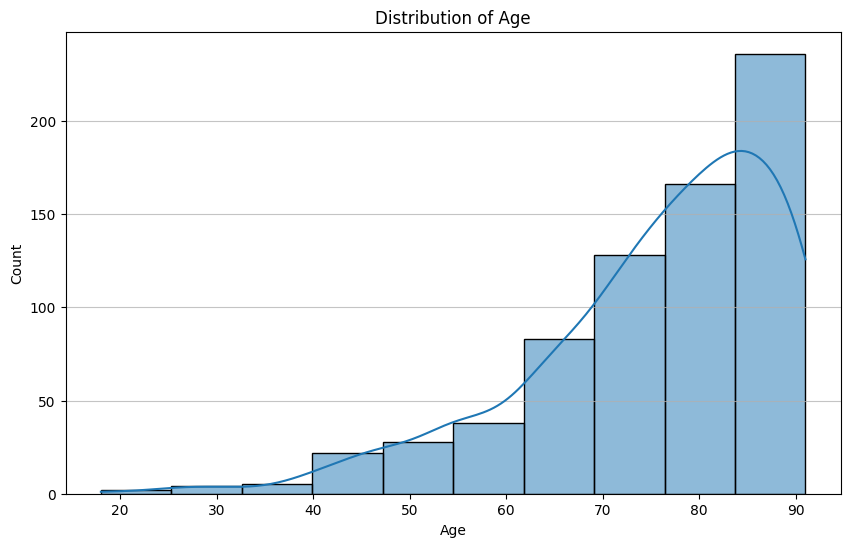

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['age'], bins=10, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

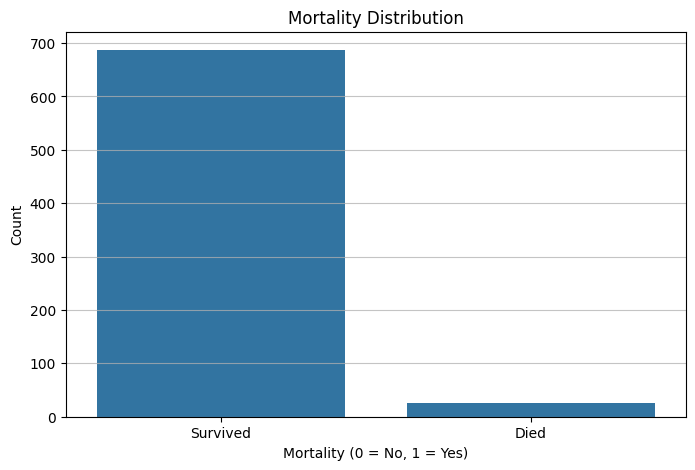

In [ ]:
# Mortality Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='mortality', data=merged_df)
plt.title('Mortality Distribution')
plt.xlabel('Mortality (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Survived', 'Died'])
plt.grid(axis='y', alpha=0.75)
plt.show()

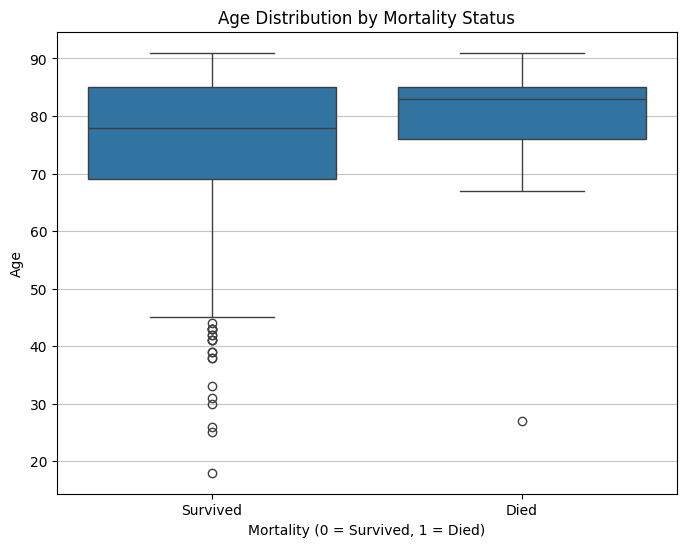

In [ ]:
# Age Distribution by Mortality Status
plt.figure(figsize=(8, 6))
sns.boxplot(x='mortality', y='age', data=merged_df)
plt.title('Age Distribution by Mortality Status')
plt.xlabel('Mortality (0 = Survived, 1 = Died)')
plt.ylabel('Age')
plt.xticks([0, 1], ['Survived', 'Died'])
plt.grid(axis='y', alpha=0.75)
plt.show()

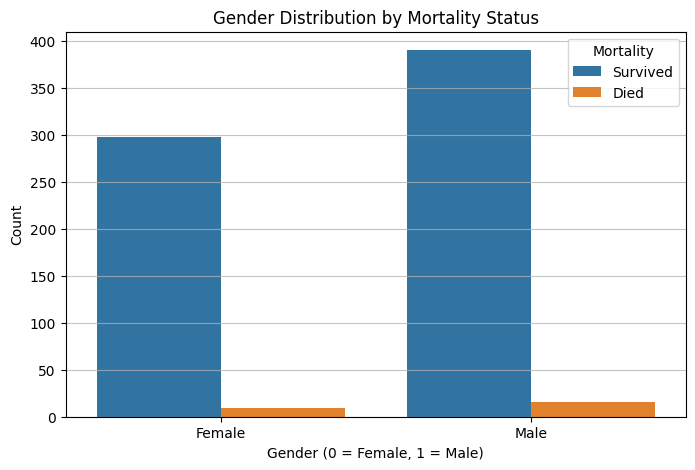

In [ ]:
# Gender Distribution by Mortality Status
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', hue='mortality', data=merged_df)
plt.title('Gender Distribution by Mortality Status')
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Female', 'Male'])
plt.legend(title='Mortality', labels=['Survived', 'Died'])
plt.grid(axis='y', alpha=0.75)
plt.show()

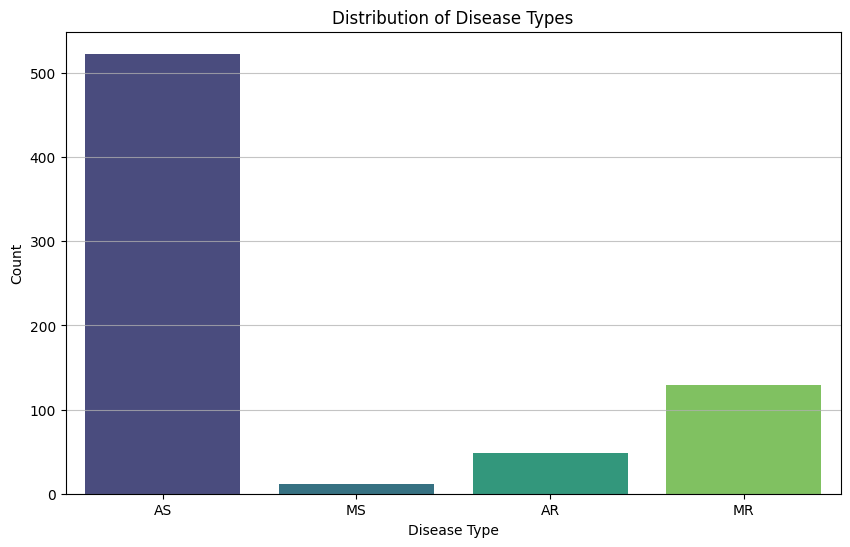

In [ ]:
# Distribution of Disease Types
plt.figure(figsize=(10, 6))
sns.countplot(x='disease_type', data=merged_df, palette='viridis', hue='disease_type', legend=False)
plt.title('Distribution of Disease Types')
plt.xlabel('Disease Type')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
df['mortality'].value_counts()

,count
mortality,
0,505
1,18


In [ ]:
print(f"\nColumns: {df.columns.tolist()}")

print(df.head())


Columns: ['hadm_id', 'subject_id', 'mortality', 'age', 'gender', 'HF', 'AF', 'CAD', 'CKD', 'COPD', 'Diabetes', 'Hypertension', 'Sepsis_IE', 'max_troponin', 'max_ntprobnp', 'first_creatinine', 'max_creatinine', 'first_urea', 'max_urea', 'min_sodium', 'max_lactate', 'min_hemoglobin', 'max_wbc', 'max_crp', 'min_bicarbonate', 'disease_type']
    hadm_id  subject_id  mortality  age  gender  HF  AF  CAD  CKD  COPD  ...  \
0  28723315    10004457          0   65       1   0   0    1    0     0  ...   
1  20015927    10017886          0   80       0   1   0    0    0     0  ...   
2  29728342    10035787          0   76       1   0   1    1    0     0  ...   
3  21350747    10051074          0   71       0   1   1    0    0     0  ...   
4  27056234    10062617          0   91       1   1   1    0    0     0  ...   

   max_creatinine  first_urea  max_urea  min_sodium  max_lactate  \
0             1.0        16.0      16.0       143.0          NaN   
1             0.7        12.0      12.0   

In [ ]:
merged_df['mortality'].value_counts()

,count
mortality,
0,687
1,25


In [ ]:
X=merged_df.drop(['mortality','subject_id','hadm_id', 'disease_type','first_creatinine','max_creatinine','first_urea','max_urea'], axis=1)
y=merged_df['mortality']
X

,age,gender,HF,AF,CAD,CKD,COPD,Diabetes,Hypertension,Sepsis_IE,max_troponin,max_ntprobnp,min_sodium,max_lactate,min_hemoglobin,max_wbc,max_crp,min_bicarbonate
0,65,1,0,0,1,0,0,0,0,0,NaN,NaN,143.0,NaN,13.7,6.5,NaN,33.0
1,80,0,1,0,0,0,0,1,1,0,NaN,250.0,140.0,NaN,11.8,4.3,NaN,31.0
2,76,1,0,1,1,0,0,0,1,0,NaN,NaN,141.0,1.3,12.6,9.0,NaN,23.0
3,71,0,1,1,0,0,0,1,0,1,0.24,1459.0,135.0,1.8,13.8,13.2,NaN,24.0
4,91,1,1,1,0,0,0,0,0,0,NaN,NaN,133.0,NaN,10.8,6.1,NaN,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,81,0,0,0,1,0,0,1,1,0,3.23,NaN,134.0,NaN,11.2,8.0,NaN,22.0
708,83,1,1,1,0,1,0,0,0,0,NaN,12997.0,128.0,NaN,9.2,6.9,NaN,24.0
709,66,1,1,0,0,0,0,1,0,0,0.24,NaN,142.0,NaN,10.0,9.9,NaN,23.0
710,75,1,1,0,1,0,0,0,1,0,NaN,NaN,140.0,NaN,14.5,5.9,NaN,27.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

In [ ]:
from sklearn.impute import SimpleImputer

# Impute missing values using the median strategy
imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame, keeping column names
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

print("Missing values after imputation:")
print(X_train_imputed.isnull().sum().sum())
print(X_test_imputed.isnull().sum().sum())

Missing values after imputation:
0
0


In [ ]:
scalar = StandardScaler()
scaled_X_train = scalar.fit_transform(X_train)
scaled_X_test = scalar.transform(X_test)

In [ ]:
scalar = StandardScaler()
scaled_X_train = scalar.fit_transform(X_train_imputed)
scaled_X_test = scalar.transform(X_test_imputed)

# Convert scaled arrays back to DataFrame for consistency with previous steps, if needed later
scaled_X_train = pd.DataFrame(scaled_X_train, columns=X_train_imputed.columns, index=X_train_imputed.index)
scaled_X_test = pd.DataFrame(scaled_X_test, columns=X_test_imputed.columns, index=X_test_imputed.index)

In [ ]:
log_model = LogisticRegression(solver='saga', max_iter=5000, class_weight='balanced')
#ConvergenceWarning two code blocks down can be fixed by increasing max_iter
#log_model = LogisticRegression(solver='saga', max_iter=10000, class_weight='balanced')

In [ ]:
penalty = ['l1', 'l2']
C=np.logspace(0,4,10)

In [ ]:
grid_model = GridSearchCV(log_model, param_grid={'C':C, 'penalty':penalty}, cv=5, scoring='roc_auc')
grid_model.fit(scaled_X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=5000, solver='saga'),
             param_grid={'C': array([1.00000000e+00, 2.78255940e+00, 7.74263683e+00, 2.15443469e+01,
       5.99484250e+01, 1.66810054e+02, 4.64158883e+02, 1.29154967e+03,
       3.59381366e+03, 1.00000000e+04]),
                         'penalty': ['l1', 'l2']},
             scoring='roc_auc')

Best parameters: {'C': np.float64(1.0), 'penalty': 'l2'}

Classification Report (Threshold 0.3):
              precision    recall  f1-score   support

           0       0.99      0.78      0.87       207
           1       0.10      0.71      0.17         7

    accuracy                           0.78       214
   macro avg       0.54      0.75      0.52       214
weighted avg       0.96      0.78      0.85       214


Confusion Matrix:
[[161  46]
 [  2   5]]

AUROC Score: 0.825


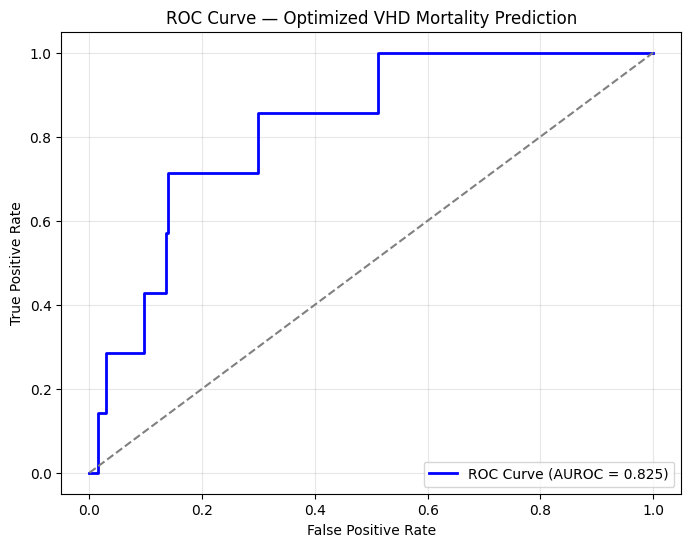

In [ ]:
# Re-calculate probabilities on scaled test data
y_prob = grid_model.predict_proba(scaled_X_test)[:, 1]

# Adjust threshold to 0.3 as requested for consistent comparison
custom_threshold = 0.3
y_pred_custom = (y_prob >= custom_threshold).astype(int)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print(f"Best parameters: {grid_model.best_params_}")
print(f"\nClassification Report (Threshold {custom_threshold}):")
print(classification_report(y_test, y_pred_custom))
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))
print(f"\nAUROC Score: {auc_score:.3f}")

# Plotting ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC Curve (AUROC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Optimized VHD Mortality Prediction")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

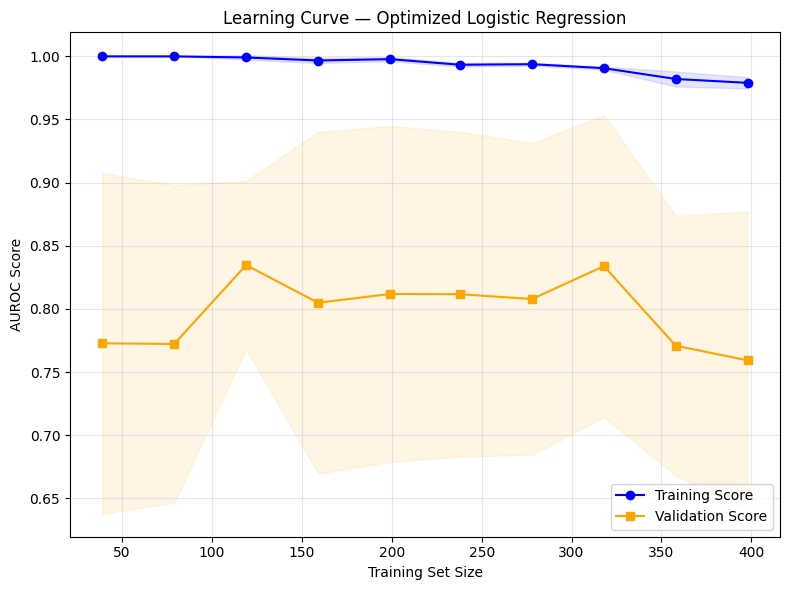

In [ ]:
from sklearn.model_selection import learning_curve

# Using the best parameters found for the Logistic Regression model
best_log_model = grid_model.best_estimator_

# Generate learning curve data
train_sizes_log, train_scores_log, val_scores_log = learning_curve(
    best_log_model,
    scaled_X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Calculate mean and standard deviation
train_mean_log = train_scores_log.mean(axis=1)
train_std_log  = train_scores_log.std(axis=1)
val_mean_log   = val_scores_log.mean(axis=1)
val_std_log    = val_scores_log.std(axis=1)

# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes_log, train_mean_log, color='blue', marker='o', label='Training Score')
plt.fill_between(train_sizes_log, train_mean_log - train_std_log, train_mean_log + train_std_log, alpha=0.1, color='blue')

plt.plot(train_sizes_log, val_mean_log, color='orange', marker='s', label='Validation Score')
plt.fill_between(train_sizes_log, val_mean_log - val_std_log, val_mean_log + val_std_log, alpha=0.1, color='orange')

plt.xlabel('Training Set Size')
plt.ylabel('AUROC Score')
plt.title('Learning Curve — Optimized Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

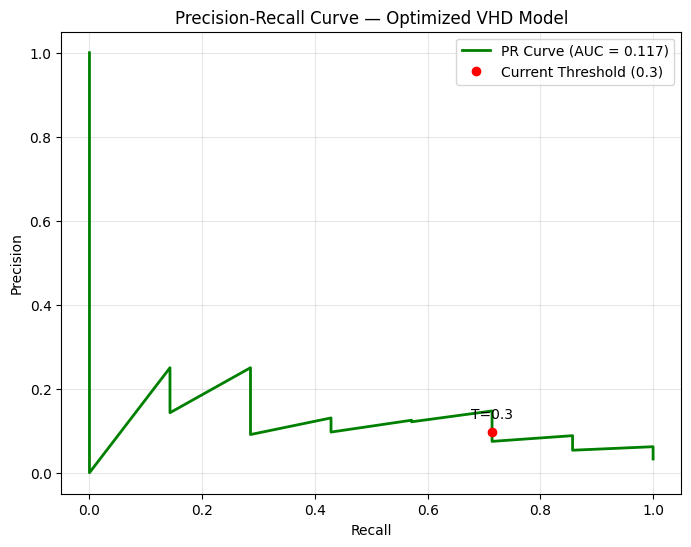

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# Calculate precision and recall for different thresholds
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='green', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Optimized VHD Model')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

# Mark the current custom threshold (0.7) on the curve
# Find the index of the threshold closest to 0.7
idx = np.argmin(np.abs(thresholds_pr - custom_threshold))
plt.plot(recall_vals[idx], precision_vals[idx], 'ro', label=f'Current Threshold ({custom_threshold})')
plt.annotate(f'T={custom_threshold}', (recall_vals[idx], precision_vals[idx]),
             textcoords="offset points", xytext=(0,10), ha='center')

plt.legend()
plt.show()

/tmp/ipykernel_1347/2503302972.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='RdBu_r')


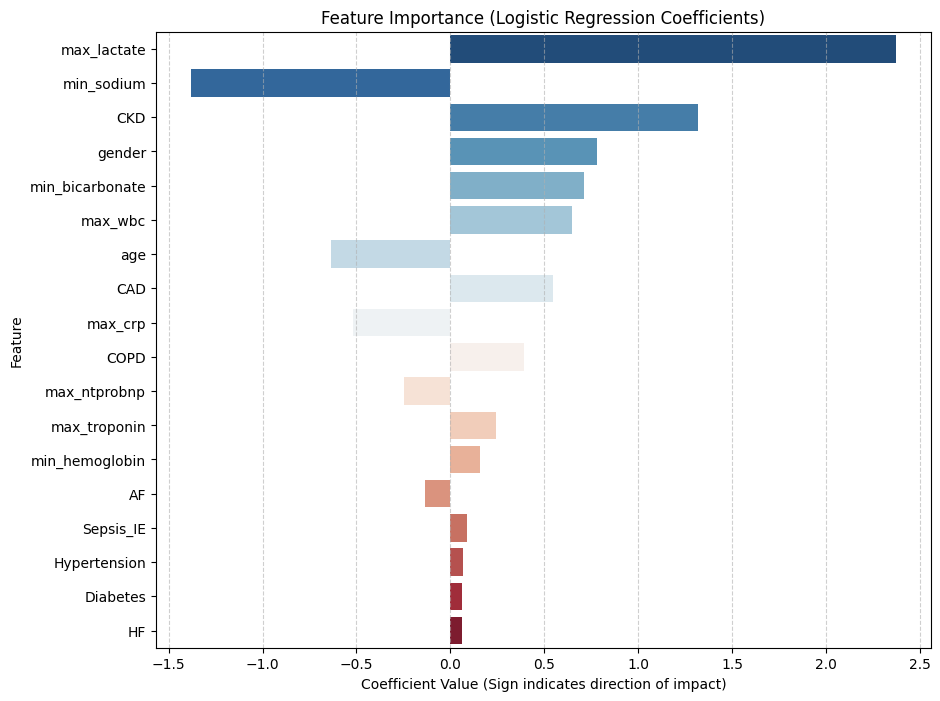

In [ ]:
# Extract coefficients from the best model
best_log_model = grid_model.best_estimator_
features = X.columns
coefficients = best_log_model.coef_[0]

# Create a DataFrame for visualization
feature_importance = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='RdBu_r')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Sign indicates direction of impact)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Feature Selection: Remove low-impact features based on coefficients
# Keeping features with absolute coefficient > 0.1
selected_features = feature_importance[feature_importance['Abs_Coefficient'] > 0.1]['Feature'].tolist()
print(f"Selected features for refinement: {selected_features}")

X_train_refined = X_train_imputed[selected_features]
X_test_refined = X_test_imputed[selected_features]

# 2. Initialize and Train Random Forest with class weighting
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 3. Grid Search for Random Forest
rf_params = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring='roc_auc')
rf_grid.fit(X_train_refined, y_train)

# 4. Evaluate Random Forest
y_prob_rf = rf_grid.predict_proba(X_test_refined)[:, 1]
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Best RF Parameters: {rf_grid.best_params_}")
print(f"Random Forest AUROC: {rf_auc:.3f}")

# Display classification report at default threshold for comparison
print("\nRF Classification Report (Default 0.5 Threshold):")
print(classification_report(y_test, rf_grid.predict(X_test_refined)))

Selected features for refinement: ['max_lactate', 'min_sodium', 'CKD', 'gender', 'min_bicarbonate', 'max_wbc', 'age', 'CAD', 'max_crp', 'COPD', 'max_ntprobnp', 'max_troponin', 'min_hemoglobin', 'AF']
Best RF Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 5}
Random Forest AUROC: 0.862

RF Classification Report (Default 0.5 Threshold):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       207
           1       0.33      0.14      0.20         7

    accuracy                           0.96       214
   macro avg       0.65      0.57      0.59       214
weighted avg       0.95      0.96      0.96       214



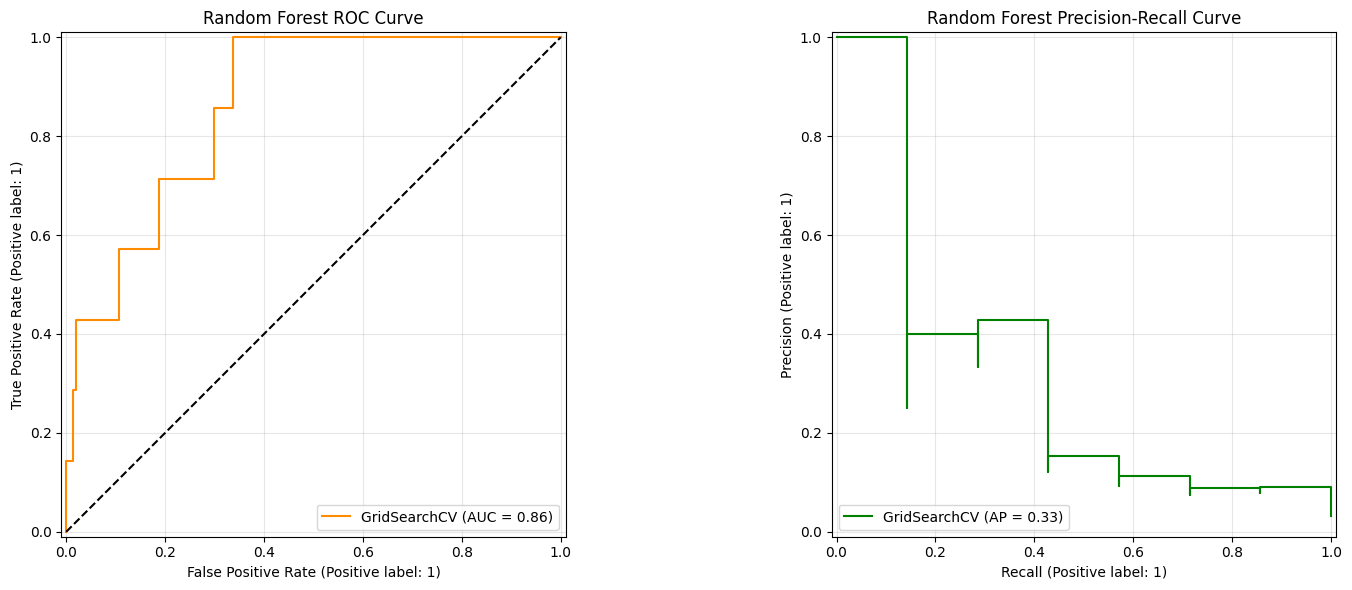

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# Create a side-by-side visualization for the Random Forest performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. ROC Curve
RocCurveDisplay.from_estimator(rf_grid, X_test_refined, y_test, ax=ax1, color='darkorange')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_title('Random Forest ROC Curve')
ax1.grid(True, alpha=0.3)

# 2. Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(rf_grid, X_test_refined, y_test, ax=ax2, color='green')
ax2.set_title('Random Forest Precision-Recall Curve')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Random Forest Performance (Threshold 0.3):
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       207
           1       0.33      0.43      0.38         7

    accuracy                           0.95       214
   macro avg       0.66      0.70      0.68       214
weighted avg       0.96      0.95      0.96       214



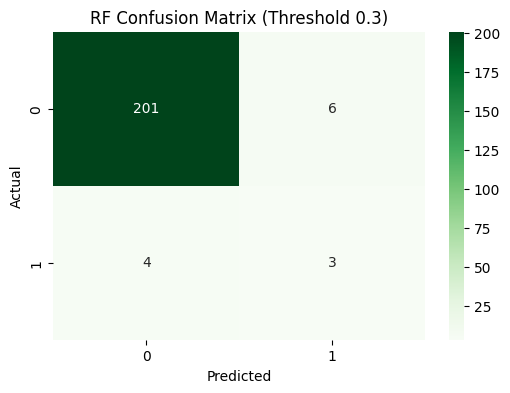

In [ ]:
# 1. Set custom threshold for Random Forest
rf_threshold = 0.3
y_pred_rf_custom = (y_prob_rf >= rf_threshold).astype(int)

# 2. Detailed Evaluation
print(f"Random Forest Performance (Threshold {rf_threshold}):")
print(classification_report(y_test, y_pred_rf_custom))

# 3. Confusion Matrix for visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf_custom), annot=True, fmt='d', cmap='Greens')
plt.title(f'RF Confusion Matrix (Threshold {rf_threshold})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Final Model Performance Summary:


,Metric,Value
0,AUROC,0.862
1,Accuracy,0.953
2,Precision (Class 1),0.333
3,Recall (Class 1),0.429
4,F1-Score (Class 1),0.375


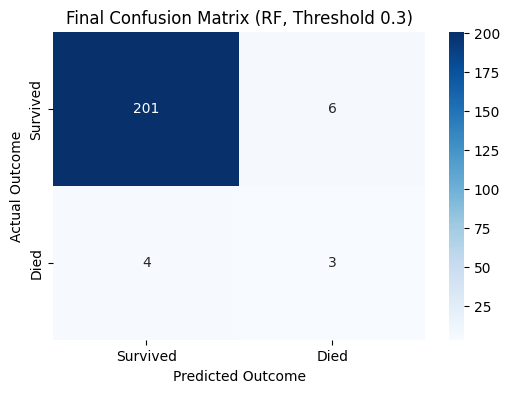

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Calculate final metrics
report = classification_report(y_test, y_pred_rf_custom, output_dict=True)
final_accuracy = accuracy_score(y_test, y_pred_rf_custom)

# Create a summary table
metrics_summary = pd.DataFrame({
    'Metric': ['AUROC', 'Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)'],
    'Value': [
        f"{rf_auc:.3f}",
        f"{final_accuracy:.3f}",
        f"{report['1']['precision']:.3f}",
        f"{report['1']['recall']:.3f}",
        f"{report['1']['f1-score']:.3f}"
    ]
})

print("Final Model Performance Summary:")
display(metrics_summary)

# Display the final Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf_custom), annot=True, fmt='d', cmap='Blues')
plt.title(f'Final Confusion Matrix (RF, Threshold {rf_threshold})')
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')
plt.xticks([0.5, 1.5], ['Survived', 'Died'])
plt.yticks([0.5, 1.5], ['Survived', 'Died'])
plt.show()

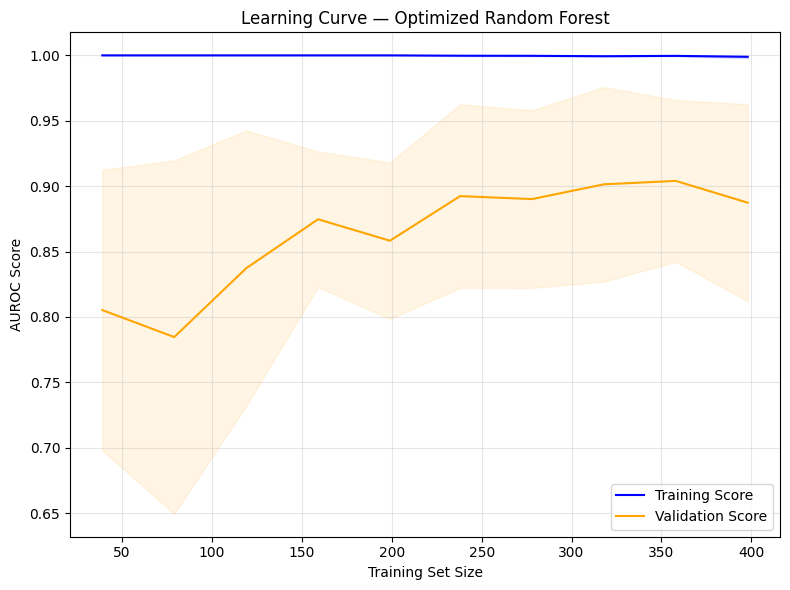

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Learning curve using the optimized Random Forest parameters
best_rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    criterion='gini',
    class_weight='balanced',
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    best_rf_model,
    X_train_refined,
    y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, color='blue', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, val_mean, color='orange', label='Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')

plt.xlabel('Training Set Size')
plt.ylabel('AUROC Score')
plt.title('Learning Curve — Optimized Random Forest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define an expanded parameter grid
refined_rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialize the Random Forest with class balancing
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# Execute Grid Search optimizing for RECALL specifically
refined_rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=refined_rf_params,
    cv=5,
    scoring='recall', # Changed from roc_auc to recall
    n_jobs=-1,
    verbose=1
)

refined_rf_grid.fit(X_train_refined, y_train)

print(f"New Best Parameters (Optimized for Recall): {refined_rf_grid.best_params_}")
print(f"Improved Training Recall: {refined_rf_grid.best_score_:.3f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
New Best Parameters (Optimized for Recall): {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Improved Training Recall: 0.117


In [ ]:
# Evaluate the refined model on the test set
y_prob_refined = refined_rf_grid.predict_proba(X_test_refined)[:, 1]
refined_auc = roc_auc_score(y_test, y_prob_refined)

# Re-apply the custom threshold to see if precision/recall improved
y_pred_refined_custom = (y_prob_refined >= 0.3).astype(int)

print(f"Refined Random Forest Test AUROC: {refined_auc:.3f}")
print("\nRefined Classification Report (Threshold 0.3):")
print(classification_report(y_test, y_pred_refined_custom))

Refined Random Forest Test AUROC: 0.890

Refined Classification Report (Threshold 0.3):
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       207
           1       0.13      0.43      0.20         7

    accuracy                           0.89       214
   macro avg       0.55      0.67      0.57       214
weighted avg       0.95      0.89      0.92       214



=== Recall-Optimized Model Performance (Threshold 0.3) ===
Test AUROC: 0.890

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       207
           1       0.13      0.43      0.20         7

    accuracy                           0.89       214
   macro avg       0.55      0.67      0.57       214
weighted avg       0.95      0.89      0.92       214



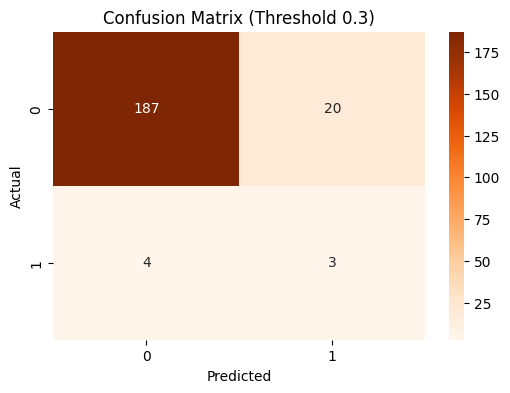

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Get probabilities from the Recall-Optimized model
y_prob_recall_opt = refined_rf_grid.predict_proba(X_test_refined)[:, 1]

# 2. Evaluate at the custom threshold (0.3) to maximize sensitivity
threshold = 0.3
y_pred_recall_opt = (y_prob_recall_opt >= threshold).astype(int)

# 3. Calculate metrics
recall_opt_auc = roc_auc_score(y_test, y_prob_recall_opt)

print("=== Recall-Optimized Model Performance (Threshold 0.3) ===")
print(f"Test AUROC: {recall_opt_auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_recall_opt))

# 4. Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_recall_opt), annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix (Threshold {threshold})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:50:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
XGBoost AUROC: 0.874

Classification Report (Threshold 0.3):
              precision    recall  f1-score   support

           0       0.99      0.85      0.91       207
           1       0.14      0.71      0.23         7

    accuracy                           0.84       214
   macro avg       0.56      0.78      0.57       214
weighted avg       0.96      0.84      0.89       214



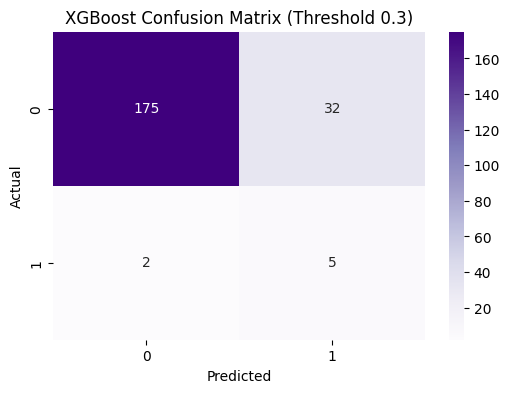

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate scale_pos_weight for class imbalance
# sum(negative) / sum(positive)
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_weight
)

# Define parameter grid
xgb_params = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Grid Search optimizing for RECALL
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

xgb_grid.fit(X_train_refined, y_train)

# Get probabilities and predictions at 0.3 threshold
y_prob_xgb = xgb_grid.predict_proba(X_test_refined)[:, 1]
threshold = 0.3
y_pred_xgb = (y_prob_xgb >= threshold).astype(int)

print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")
print(f"XGBoost AUROC: {roc_auc_score(y_test, y_prob_xgb):.3f}")
print("\nClassification Report (Threshold 0.3):")
print(classification_report(y_test, y_pred_xgb))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Purples')
plt.title(f'XGBoost Confusion Matrix (Threshold {threshold})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

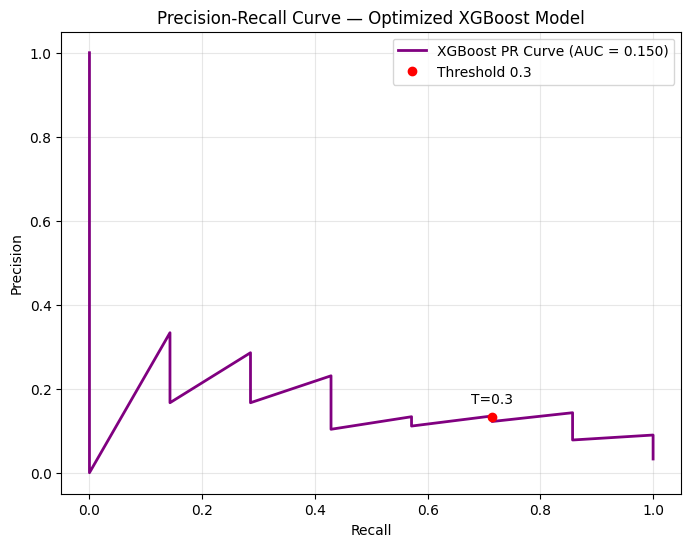

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# Calculate precision and recall for the XGBoost model
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_prob_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, color='purple', lw=2, label=f'XGBoost PR Curve (AUC = {pr_auc_xgb:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Optimized XGBoost Model')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

# Mark the custom threshold (0.3) on the curve
# Note: thresholds_xgb has length len(precision_xgb) - 1
idx_xgb = np.argmin(np.abs(thresholds_xgb - 0.3))
plt.plot(recall_xgb[idx_xgb], precision_xgb[idx_xgb], 'ro', label='Threshold 0.3')
plt.annotate('T=0.3', (recall_xgb[idx_xgb], precision_xgb[idx_xgb]),
             textcoords="offset points", xytext=(0,10), ha='center')

plt.legend()
plt.show()

=== Three-Way Model Performance Comparison ===


,Model,AUROC,Recall (Class 1),Precision (Class 1),F1-Score (Class 1),Threshold
2,XGBoost,0.874396,0.714286,0.135135,0.227273,0.3
0,Logistic Regression,0.824707,0.428571,0.107143,0.171429,0.7
1,Random Forest,0.889579,0.428571,0.130435,0.200000,0.3


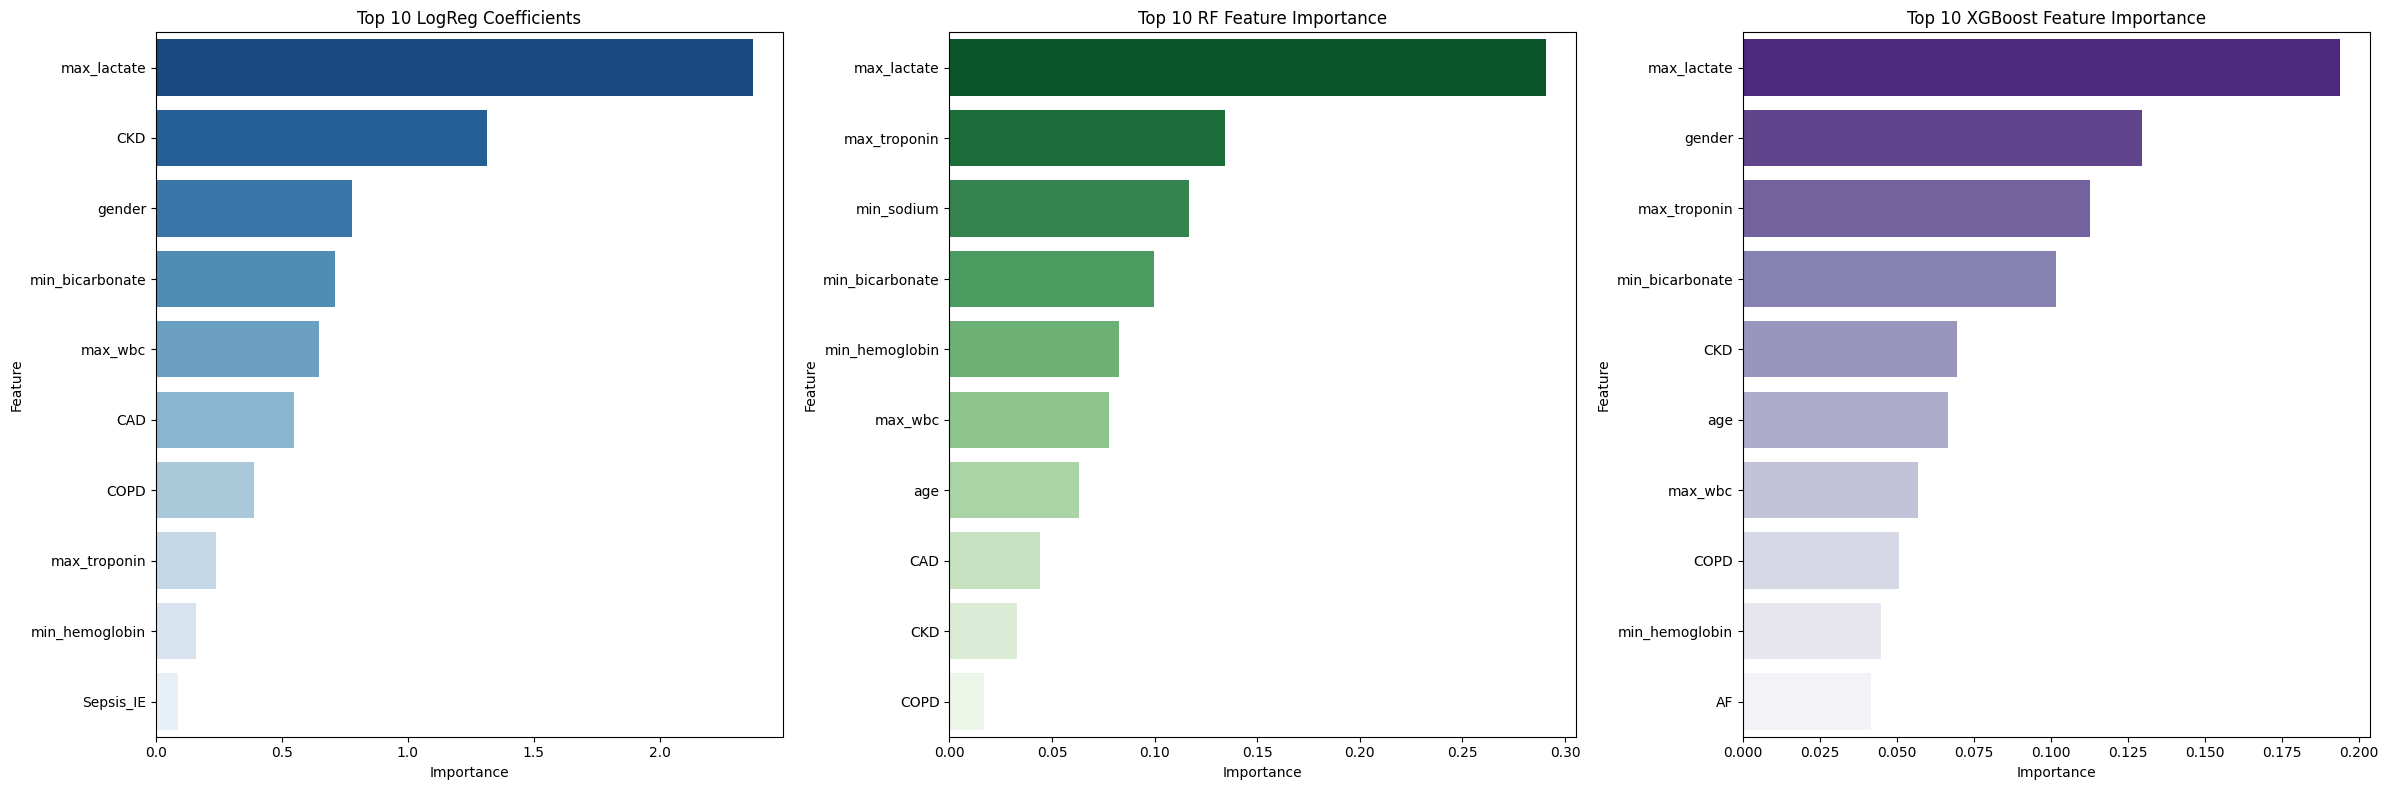

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score

# 1. Collect results from all models using model-specific thresholds
# Logistic Regression is kept at 0.7 per user request; ensembles stay at 0.3
models_data = {
    'Logistic Regression': (grid_model, scaled_X_test, 0.7),
    'Random Forest': (refined_rf_grid, X_test_refined, 0.3),
    'XGBoost': (xgb_grid, X_test_refined, 0.3)
}

comparison_list = []

for name, (model, test_data, threshold) in models_data.items():
    probs = model.predict_proba(test_data)[:, 1]
    preds = (probs >= threshold).astype(int)
    report = classification_report(y_test, preds, output_dict=True)

    comparison_list.append({
        'Model': name,
        'AUROC': roc_auc_score(y_test, probs),
        'Recall (Class 1)': report['1']['recall'],
        'Precision (Class 1)': report['1']['precision'],
        'F1-Score (Class 1)': report['1']['f1-score'],
        'Threshold': threshold
    })

# 2. Display Performance Summary
performance_df = pd.DataFrame(comparison_list)
print("=== Three-Way Model Performance Comparison ===")
display(performance_df.sort_values(by='Recall (Class 1)', ascending=False))

# 3. Feature Importance Comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

# Log Regression Coefficients
log_feat = pd.DataFrame({'Feature': X.columns, 'Importance': grid_model.best_estimator_.coef_[0]}).sort_values('Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=log_feat.head(10), ax=ax1, palette='Blues_r', hue='Feature', legend=False)
ax1.set_title('Top 10 LogReg Coefficients')

# Random Forest Gini Importance
rf_feat = pd.DataFrame({'Feature': selected_features, 'Importance': refined_rf_grid.best_estimator_.feature_importances_}).sort_values('Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=rf_feat.head(10), ax=ax2, palette='Greens_r', hue='Feature', legend=False)
ax2.set_title('Top 10 RF Feature Importance')

# XGBoost Gain Importance
xgb_feat = pd.DataFrame({'Feature': selected_features, 'Importance': xgb_grid.best_estimator_.feature_importances_}).sort_values('Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=xgb_feat.head(10), ax=ax3, palette='Purples_r', hue='Feature', legend=False)
ax3.set_title('Top 10 XGBoost Feature Importance')

plt.tight_layout()
plt.show()

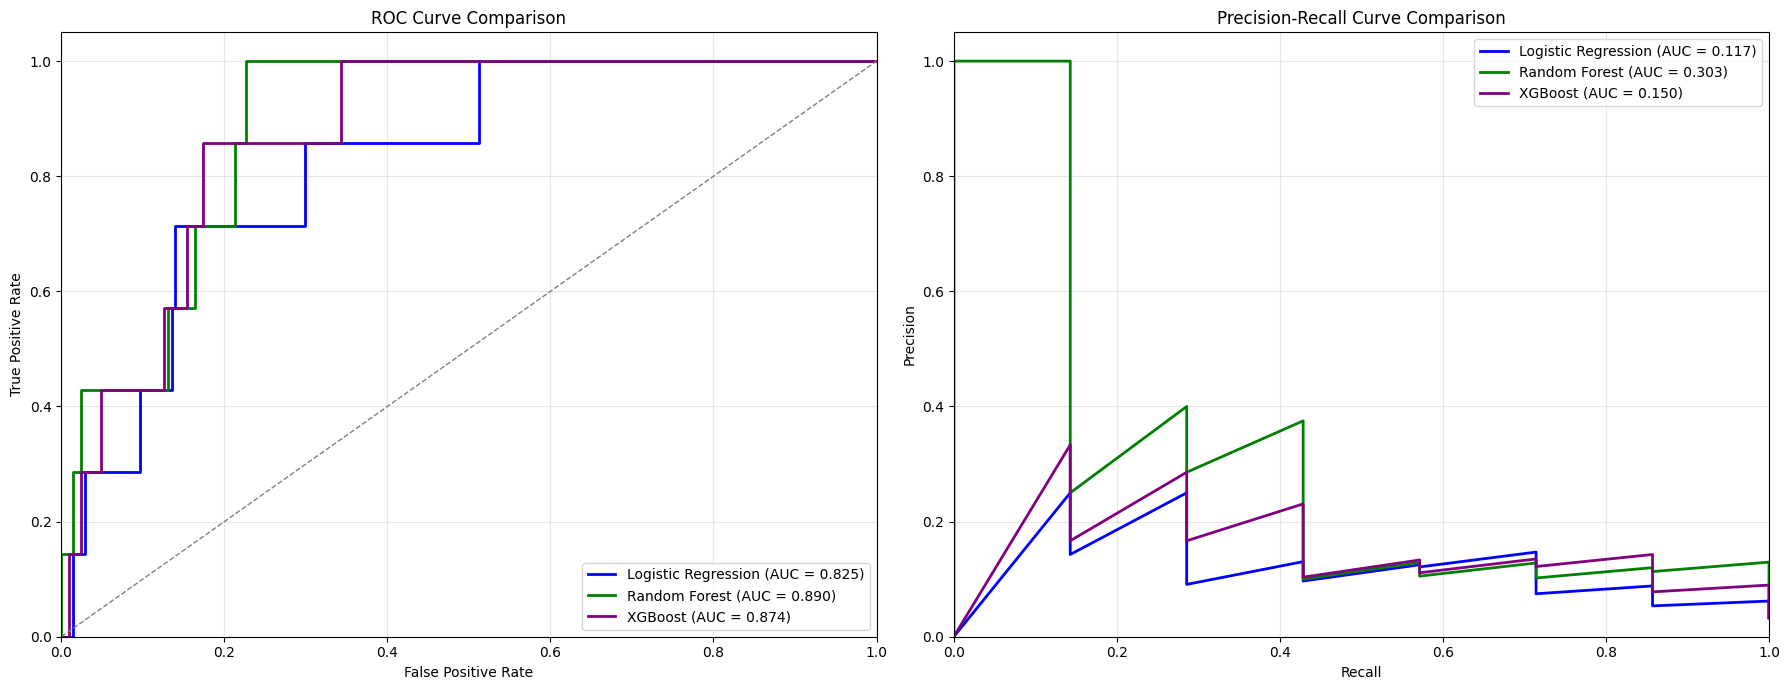

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# 1. Prepare data for plotting
# We'll use the probabilities calculated in previous steps
model_probs = {
    'Logistic Regression': (y_test, y_prob),
    'Random Forest': (y_test, y_prob_refined),
    'XGBoost': (y_test, y_prob_xgb)
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
colors = {'Logistic Regression': 'blue', 'Random Forest': 'green', 'XGBoost': 'purple'}

# 2. Plot ROC Curves
for name, (y_true, y_score) in model_probs.items():
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=colors[name], lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve Comparison')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# 3. Plot Precision-Recall Curves
for name, (y_true, y_score) in model_probs.items():
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)
    ax2.plot(recall, precision, color=colors[name], lw=2, label=f'{name} (AUC = {pr_auc:.3f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve Comparison')
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

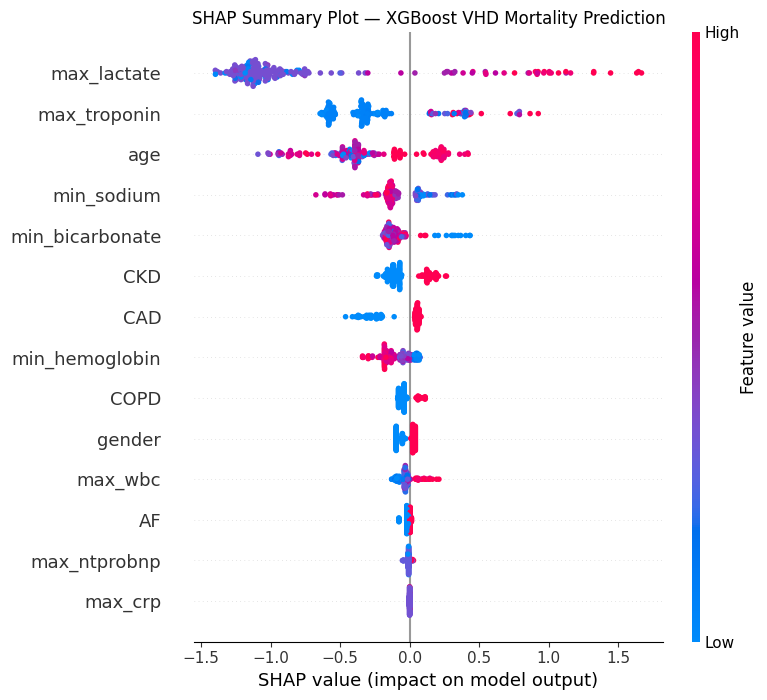

In [ ]:
#SHAP Summary plot


!pip install shap

import shap

best_xgb = xgb_grid.best_estimator_

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test_refined)

# Plot 1
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_refined,
    plot_type="dot",
    show=False
)
plt.title("SHAP Summary Plot — XGBoost VHD Mortality Prediction")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group 5: Dereck Kaale/shap_summary.png',
            dpi=300, bbox_inches='tight')
plt.show()


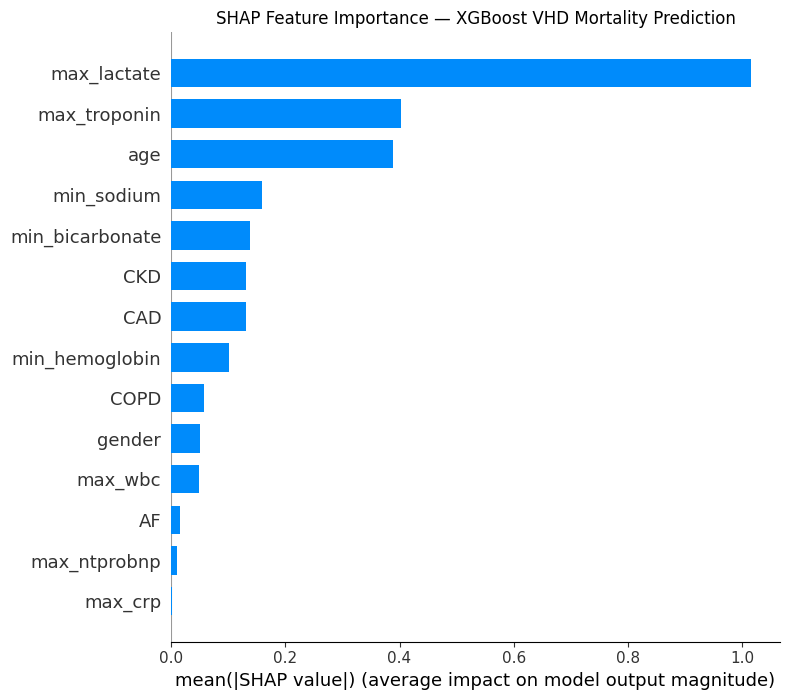

In [ ]:
# Plot 2: SHAP Bar Plot (Mean importance)
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_refined,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance — XGBoost VHD Mortality Prediction")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group 5: Dereck Kaale/shap_bar.png',
            dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Plot 3: SHAP values as a table
shap_df = pd.DataFrame({
    'Feature': X_test_refined.columns,
    'Mean SHAP Value': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean SHAP Value', ascending=False).reset_index(drop=True)

print("=== SHAP Feature Importance Table ===")
display(shap_df)

=== SHAP Feature Importance Table ===


,Feature,Mean SHAP Value
0,max_lactate,1.015507
1,max_troponin,0.403258
2,age,0.389027
3,min_sodium,0.158776
4,min_bicarbonate,0.137469
5,CKD,0.130955
6,CAD,0.130714
7,min_hemoglobin,0.101234
8,COPD,0.057051
9,gender,0.050065


In [ ]:
best_rf = refined_rf_grid.best_estimator_

# Random Forest
explainer = shap.TreeExplainer(best_rf)


shap_values = explainer.shap_values(X_test_refined)

shap_values_class1 = shap_values[:, :, 1]



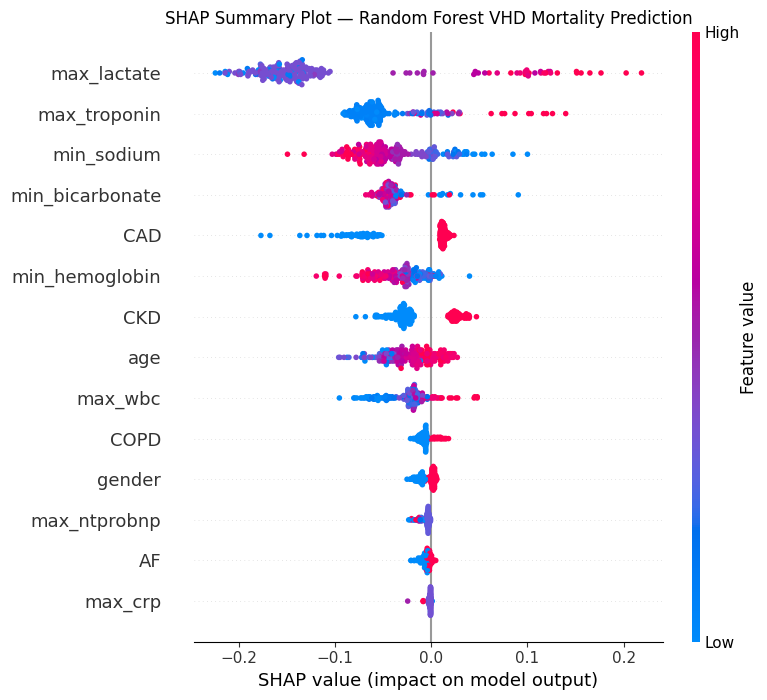

In [ ]:
plt.figure()
shap.summary_plot(
    shap_values_class1,
    X_test_refined,
    plot_type="dot",
    show=False
)
plt.title("SHAP Summary Plot — Random Forest VHD Mortality Prediction")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group 5: Dereck Kaale/shap_rf_summary.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def create_characteristics_table(df):
    # Define variables to summarize
    demographics = ['age', 'gender']
    comorbidities_list = ['HF', 'AF', 'CAD', 'CKD', 'COPD', 'Diabetes', 'Hypertension', 'Sepsis_IE']
    labs = ['max_troponin', 'max_ntprobnp', 'max_creatinine', 'min_sodium', 'max_lactate', 'min_hemoglobin', 'max_wbc', 'min_bicarbonate']

    results = []

    # Helper to get summary based on groups
    groups = {'Overall': df, 'Survived': df[df['mortality'] == 0], 'Died': df[df['mortality'] == 1]}

    summary_data = {}
    for g_name, g_df in groups.items():
        col_results = {}
        col_results['N'] = len(g_df)

        # Continuous Variables (Mean ± SD)
        for var in demographics + labs:
            mean = g_df[var].mean()
            std = g_df[var].std()
            col_results[var] = f"{mean:.1f} ± {std:.1f}" if not np.isnan(mean) else "N/A"

        # Categorical Variables (n, %)
        for var in comorbidities_list:
            count = g_df[var].sum()
            percent = (count / len(g_df)) * 100 if len(g_df) > 0 else 0
            col_results[var] = f"{int(count)} ({percent:.1f}%)"

        # Special case for Gender (Male count)
        male_count = g_df['gender'].sum()
        male_per = (male_count / len(g_df)) * 100 if len(g_df) > 0 else 0
        col_results['gender'] = f"{int(male_count)} ({male_per:.1f}%)"

        summary_data[g_name] = col_results

    # Convert to DataFrame
    table = pd.DataFrame(summary_data)

    # Reorder index for better presentation
    ordered_index = ['N', 'age', 'gender'] + comorbidities_list + labs
    table = table.reindex(ordered_index)

    # Rename indices for display
    rename_dict = {
        'age': 'Age (years)',
        'gender': 'Sex (Male, %)',
        'HF': 'Heart Failure (%)',
        'AF': 'Atrial Fibrillation (%)',
        'CAD': 'Coronary Artery Disease (%)',
        'CKD': 'Chronic Kidney Disease (%)',
        'COPD': 'COPD (%)',
        'Diabetes': 'Diabetes (%)',
        'Hypertension': 'Hypertension (%)',
        'Sepsis_IE': 'Sepsis/IE (%)',
        'max_troponin': 'Troponin T (max)',
        'max_ntprobnp': 'NTproBNP (max)',
        'max_creatinine': 'Creatinine (max)',
        'min_sodium': 'Sodium (min)',
        'max_lactate': 'Lactate (max)',
        'min_hemoglobin': 'Hemoglobin (min)',
        'max_wbc': 'WBC (max)',
        'min_bicarbonate': 'Bicarbonate (min)'
    }
    table.index = [rename_dict.get(x, x) for x in table.index]

    return table

# Generate the table
pop_char_table = create_characteristics_table(merged_df)
print("Population Characteristics Table")
display(pop_char_table)

Population Characteristics Table


,Overall,Survived,Died
N,712,687,25
Age (years),75.5 ± 13.2,75.4 ± 13.2,79.2 ± 12.7
"Sex (Male, %)",406 (57.0%),390 (56.8%),16 (64.0%)
Heart Failure (%),508 (71.3%),489 (71.2%),19 (76.0%)
Atrial Fibrillation (%),312 (43.8%),296 (43.1%),16 (64.0%)
Coronary Artery Disease (%),471 (66.2%),449 (65.4%),22 (88.0%)
Chronic Kidney Disease (%),219 (30.8%),203 (29.5%),16 (64.0%)
COPD (%),124 (17.4%),117 (17.0%),7 (28.0%)
Diabetes (%),231 (32.4%),225 (32.8%),6 (24.0%)
Hypertension (%),306 (43.0%),301 (43.8%),5 (20.0%)
